In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

Matplotlib is building the font cache; this may take a moment.


In [2]:
file_path = '/Users/yanapathak/Downloads/cleaned_discipline_specific_pathways (1).csv'
df = pd.read_csv(file_path)

In [3]:
print("Column Names in Dataset:")
print(df.columns.tolist())

df.head()

Column Names in Dataset:
['Focal Award', 'Discipline', 'Pathway Award', '# Awardees w/ This Award', 'Percentage of Awardees with This Award', 'Mean Academic Age at Time of Award']


,Focal Award,Discipline,Pathway Award,# Awardees w/ This Award,Percentage of Awardees with This Award,Mean Academic Age at Time of Award
0,A-T Children's Project | AT Research Grants,Pathology,Association for Molecular Pathology | AMP Youn...,1.0,1.0,10.0
1,A-T Children's Project | AT Research Grants,Pathology,A-T Children's Project | AT Research Grants,1.0,1.0,21.0
2,Abdullah bin Hamad Al-Attiyah International Fo...,"Engineering, various","Society of Petroleum Engineers | Health, Safet...",1.0,1.0,31.0
3,Abdullah bin Hamad Al-Attiyah International Fo...,"Engineering, various","Geological Society of America, The | Michel T ...",1.0,1.0,21.0
4,Abdullah bin Hamad Al-Attiyah International Fo...,Environmental Sciences,"Society of Petroleum Engineers | Health, Safet...",1.0,1.0,31.0


In [4]:
print("\nSummary Statistics:")
print(df.describe())

print("\nBasic Info:")
print(df.info())

print("\nUnique Disciplines:")
print(df['Discipline'].nunique())

print("\nUnique Awards:")
print(df['Focal Award'].nunique())


Summary Statistics:
       # Awardees w/ This Award  Percentage of Awardees with This Award  \
count             182704.000000                           182705.000000   
mean                   1.251270                                0.559009   
std                    1.538589                                0.388555   
min                    1.000000                                0.005000   
25%                    1.000000                                0.200000   
50%                    1.000000                                0.500000   
75%                    1.000000                                1.000000   
max                  154.000000                                1.000000   

       Mean Academic Age at Time of Award  
count                       169798.000000  
mean                            16.920694  
std                             11.359194  
min                              0.000000  
25%                              7.000000  
50%                             15.0000

In [5]:
# award liklihood across disciplines

discipline_award_counts = pd.crosstab(df['Discipline'], df['Focal Award'])
chi2, p, _, _ = stats.chi2_contingency(discipline_award_counts)
print("\nChi-Square Test for Award Likelihood Across Disciplines:")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test for Award Likelihood Across Disciplines:
Chi2: 5583615.282427399, p-value: 0.0


The extremely high chi-square statistic and p-value < 0.05 indicate that award distribution significantly varies across disciplines. This suggests that some disciplines are more likely to receive certain awards than others.

In [6]:
#  impact of prior awards on receiving another award

df['Has Pathway Award'] = df['Pathway Award'].apply(lambda x: 1 if pd.notna(x) else 0)
df['Has Focal Award'] = df['Focal Award'].apply(lambda x: 1 if pd.notna(x) else 0)
prior_award_counts = pd.crosstab(df['Has Pathway Award'], df['Has Focal Award'])
chi2, p, _, _ = stats.chi2_contingency(prior_award_counts)
print("\nChi-Square Test for Impact of Prior Awards on Receiving Another Award:")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test for Impact of Prior Awards on Receiving Another Award:
Chi2: 0.0, p-value: 1.0


The chi-square statistic of 0 suggests that the two variables (having a prior award and receiving a focal award) are completely independent—meaning that receiving a prior award does not affect the likelihood of receiving a future award in this dataset.

In [7]:
# do different disciplines favor specific pathway awards?

discipline_pathway_counts = pd.crosstab(df['Discipline'], df['Pathway Award'])
chi2, p, _, _ = stats.chi2_contingency(discipline_pathway_counts)
print("\nChi-Square Test for Relationship Between Disciplines and Pathway Awards:")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test for Relationship Between Disciplines and Pathway Awards:
Chi2: 4501730.299500342, p-value: 0.0


The significant p-value suggests that disciplines and pathway awards are not independent. This means that some disciplines are more associated with certain pathway awards than others.

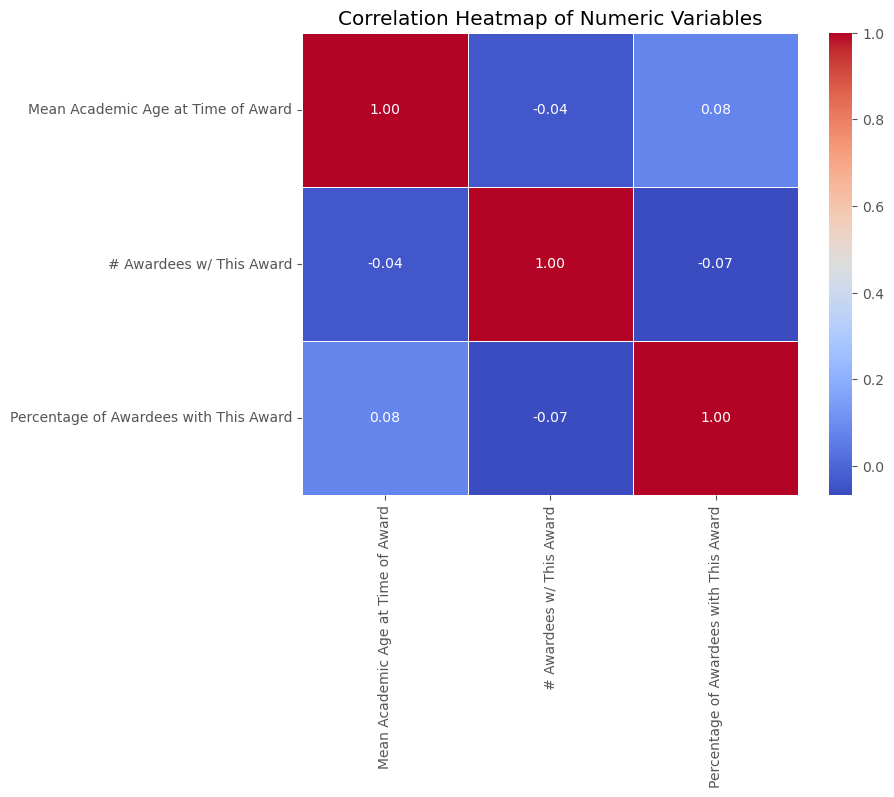

In [8]:
plt.style.use('ggplot')

# correlation matrix

plt.figure(figsize=(8, 6))
corr_matrix = df[["Mean Academic Age at Time of Award", "# Awardees w/ This Award", "Percentage of Awardees with This Award"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

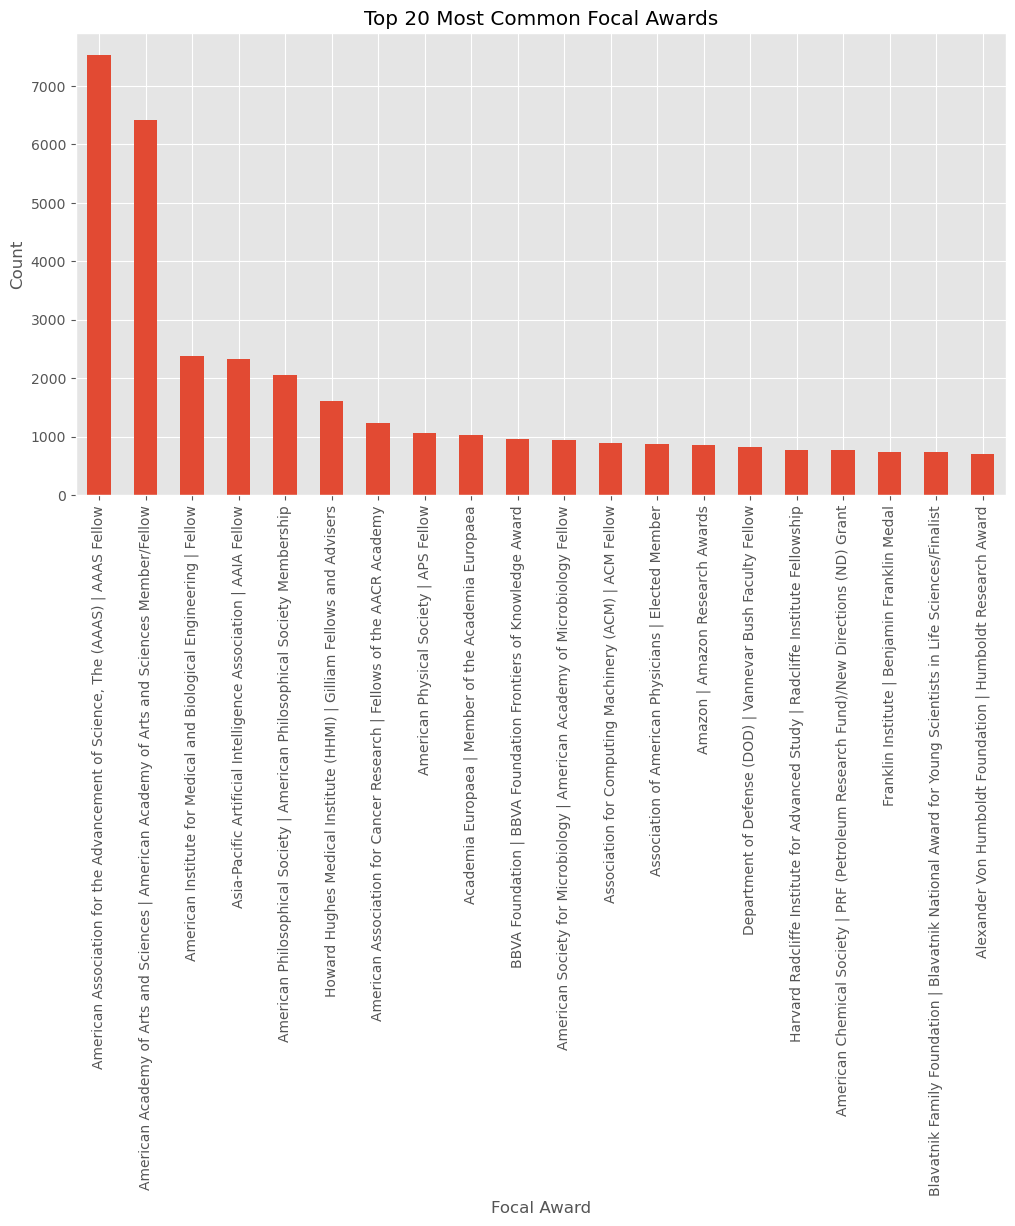

In [9]:
# most common focal awards, top 20

plt.figure(figsize=(12, 6))
df["Focal Award"].value_counts().nlargest(20).plot(kind="bar")
plt.xlabel("Focal Award")
plt.ylabel("Count")
plt.title("Top 20 Most Common Focal Awards")
plt.xticks(rotation=90)
plt.show()

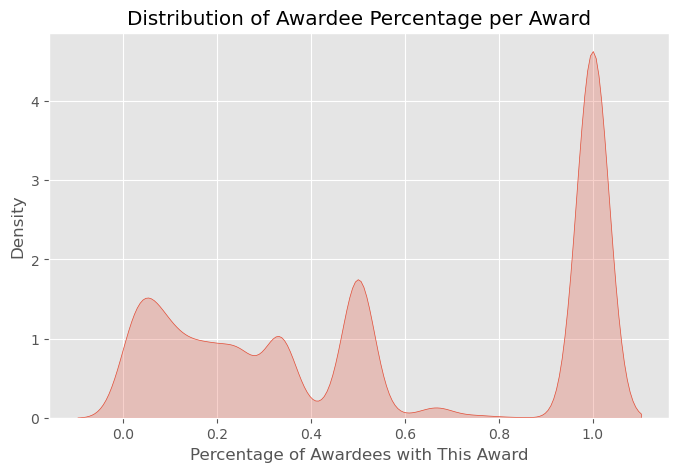

In [10]:
# distribution of percentage of awardees with this award

plt.figure(figsize=(8, 5))
sns.kdeplot(df["Percentage of Awardees with This Award"], fill=True)
plt.xlabel("Percentage of Awardees with This Award")
plt.ylabel("Density")
plt.title("Distribution of Awardee Percentage per Award")
plt.show()

In [11]:
# relationship between discipline and receiving multiple awards

df['Received Multiple Awards'] = df.groupby('Focal Award')['Focal Award'].transform('count') > 1
discipline_award_counts = pd.crosstab(df['Discipline'], df['Received Multiple Awards'])
chi2, p, _, _ = stats.chi2_contingency(discipline_award_counts)
print("\nChi-Square Test: Is There a Relationship Between Discipline and Receiving Multiple Awards?")
print(f"Chi2: {chi2}, p-value: {p}")


Chi-Square Test: Is There a Relationship Between Discipline and Receiving Multiple Awards?
Chi2: 1077.2180659983508, p-value: 2.8733019638079092e-129


A higher Chi2 value suggests a stronger relationship between the variables. This is an extremely small p-value, far below the 0.05 significance threshold.
Since p < 0.05, we reject the null hypothesis → Discipline and receiving multiple awards are NOT independent.
This means that some disciplines are significantly more likely to receive multiple awards than others.

In [12]:
# do some pathway awards lead to higher awardee percentages?

kruskal_stat, p_kruskal = stats.kruskal(*[group["Percentage of Awardees with This Award"].dropna().values
                                           for name, group in df.groupby("Pathway Award")])

print("\nKruskal-Wallis Test: Do Some Pathway Awards Lead to Higher Awardee Percentages?")
print(f"Kruskal Statistic: {kruskal_stat}, p-value: {p_kruskal}")


Kruskal-Wallis Test: Do Some Pathway Awards Lead to Higher Awardee Percentages?
Kruskal Statistic: 32700.149966373585, p-value: 0.0


A higher Kruskal statistic suggests a stronger difference between groups. The p-value is essentially 0, which means there is an extremely significant difference between at least one group compared to the others. Since p < 0.05, we reject the null hypothesis → Not all Pathway Awards have the same distribution of awardee percentages. Some awards likely have much higher awardee percentages than others.

Some pathway awards are more strongly associated with higher awardee percentages than others.
Will want to include pathway award type as a categorical feature in predictive model.

In [13]:
# feature importance using decision trees
# what variables best predict focal awards?

df_encoded = df.copy()
for col in ['Discipline', 'Pathway Award', 'Focal Award']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded[['Discipline', 'Pathway Award', 'Has Pathway Award', 'Mean Academic Age at Time of Award', '# Awardees w/ This Award']]
y = df_encoded['Focal Award']

# training
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

# feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

print("\nFeature Importance Using Decision Trees:")
print(feature_importances)


Feature Importance Using Decision Trees:
                              Feature  Importance
1                       Pathway Award    0.599747
3  Mean Academic Age at Time of Award    0.283202
0                          Discipline    0.098983
4            # Awardees w/ This Award    0.018060
2                   Has Pathway Award    0.000009


"Pathway Award" is the most predictive feature (60%): Instead of just checking if a person has a Pathway Award (Has Pathway Award), the specific type of Pathway Award matters a lot. Could group similar pathway awards  predictive model.

"Mean Academic Age at Time of Award" (28%) is a strong factor: Recipients at certain academic ages are more likely to receive Focal Awards. Maybe bin ages (e.g., early career, mid-career, senior career) to improve model performance.

"Discipline" has moderate importance (~10%): Different disciplines have different likelihoods of receiving awards, so it should still be included as a feature. Rename disciplines into meaningful categories instead of using raw labels?

"# Awardees w/ This Award" is not very predictive (1.8%): The overall number of awardees does not strongly determine individual likelihood. Could test other award-related metrics (e.g., selectivity rate, competition level).

"Has Pathway Award" has zero predictive value: Simply having any Pathway Award is not enough to predict a Focal Award, better to focus on the specific Pathway Award type instead of a simple Yes/No flag.
